## **Character distribution — original transcription vs. synthetic-seed lines vs. COMETA corpus vs. medical_texts corpus**

Compare the per-character frequency across four sources to make sure the lines we feed the synthetic-image generator are linguistically representative of (a) the real manuscript we're targeting and (b) the broader medieval corpora we draw from:

1. **AlbucE.txt** — the human transcription of the reference manuscript (single file).
2. **`cometa_categorized.json` seed lines** — the COMETA-derived filtered subset (output of `corpus_categorization`).
3. **COMETA medieval corpus** — every `*.txt` file under `data/raw/COMETA_medieval_corpus/` (the unfiltered COMETA superset).
4. **medical_texts corpus** — every `*.txt` file under `data/raw/medical_texts/` (the new paragraph-style corpus that feeds `medical_texts_categorization` via cut-to-lines + keep-all).

Sections:

1. **Setup** — imports + paths.
2. **Load each source** — extract raw text from disk / JSON.
3. **Per-source character frequency** — counts and fractions.
4. **Side-by-side comparison** — merged table, set differences.
5. **Visual comparison** — bar charts on linear and log scales.
6. **Drill-down: characters unique to a source** — what one source has that the others don't.


### 1. Setup

In [1]:
import json
import os
import re
import sys
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = Path(os.environ["PROJECT_ROOT"])

# Make `src.*` importable when the kernel was launched outside the project root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ALBUC_TXT          = PROJECT_ROOT / "data/raw/AlbucE.txt"
CATEGORIZED_JSON   = PROJECT_ROOT / "data/processed/synthetic_seeds/categorize_20260613_214958/cometa_categorized.json"
COMETA_DIR         = PROJECT_ROOT / "data/raw/COMETA_medieval_corpus"
MEDICAL_TEXTS_DIR  = PROJECT_ROOT / "data/raw/medical_texts"

print(f"AlbucE:           {ALBUC_TXT}")
print(f"Categorized seed: {CATEGORIZED_JSON}")
print(f"COMETA corpus:    {COMETA_DIR}")
print(f"medical_texts:    {MEDICAL_TEXTS_DIR}")


AlbucE:           /Users/camilabermudezvalderrama/Documents/LMU-STATISTICS & DATA SCIENCE MASTER/SS2026/Thesis/OCC_HTR/data/raw/AlbucE.txt
Categorized seed: /Users/camilabermudezvalderrama/Documents/LMU-STATISTICS & DATA SCIENCE MASTER/SS2026/Thesis/OCC_HTR/data/processed/synthetic_seeds/categorize_20260613_214958/cometa_categorized.json
COMETA corpus:    /Users/camilabermudezvalderrama/Documents/LMU-STATISTICS & DATA SCIENCE MASTER/SS2026/Thesis/OCC_HTR/data/raw/COMETA_medieval_corpus
medical_texts:    /Users/camilabermudezvalderrama/Documents/LMU-STATISTICS & DATA SCIENCE MASTER/SS2026/Thesis/OCC_HTR/data/raw/medical_texts


### 2. Load each source

Each loader returns the raw text concatenation that we'll count over. Loading the COMETA corpus walks every `*.txt` file (the matching `.pdf` files are ignored).

In [2]:
def load_albuc(path: Path) -> str:
    """Single-file plain-text transcription of the target manuscript."""
    return path.read_text(encoding="utf-8")


def load_categorized_seeds(path: Path) -> str:
    """Concatenated text from every record in the categorized seed JSON."""
    doc = json.loads(path.read_text(encoding="utf-8"))
    samples = doc.get("samples") or {}
    return "\n".join(s.get("text", "") for s in samples.values())


def load_corpus_dir(dirpath: Path) -> str:
    """Concatenated text from every *.txt file under a corpus directory.

    Used for both COMETA and medical_texts — same shape on disk (a flat
    folder of .txt files), so a single loader suffices.
    """
    parts = []
    for f in sorted(dirpath.glob("*.txt")):
        parts.append(f.read_text(encoding="utf-8", errors="replace"))
    return "\n".join(parts)


sources = {
    "AlbucE":           load_albuc(ALBUC_TXT),
    "categorized_seed": load_categorized_seeds(CATEGORIZED_JSON),
    "COMETA_full":      load_corpus_dir(COMETA_DIR),
    "medical_texts":    load_corpus_dir(MEDICAL_TEXTS_DIR),
}

print(f"{'source':<20} {'chars':>12} {'unique':>8} {'lines':>10}")
for name, text in sources.items():
    n_lines = text.count("\n") + 1
    print(f"{name:<20} {len(text):>12,} {len(set(text)):>8} {n_lines:>10,}")


source                      chars   unique      lines
AlbucE                    533,821       60      3,521
categorized_seed        2,999,638       75     88,826
COMETA_full             3,867,197       76    127,878
medical_texts             419,272       67        600


### 3. Per-source character frequency

For each source, count every character (yes, including whitespace and punctuation) and convert to a fraction of the total so the three sources are comparable despite their different sizes.

In [3]:
def char_distribution(text: str) -> pd.DataFrame:
    """Return a DataFrame with columns ['char', 'count', 'fraction']."""
    c = Counter(text)
    total = sum(c.values())
    df = pd.DataFrame(
        [(ch, n, n / total) for ch, n in c.items()],
        columns=["char", "count", "fraction"],
    )
    return df.sort_values("count", ascending=False).reset_index(drop=True)


per_source = {name: char_distribution(text) for name, text in sources.items()}

# Top-N per source side by side — using the UNION of each source's top N
# and then looking each char up in the FULL distribution. Otherwise a
# char that's 11th in one source and 8th in another gets a fabricated 0
# from `df.head(N)` truncation (which would falsely tell you AlbucE has
# no `n`).
top_n = 10
top_chars = list({c for df in per_source.values() for c in df["char"].head(top_n)})
preview = pd.concat(
    {name: df.set_index("char")["fraction"].rename(name) for name, df in per_source.items()},
    axis=1,
).fillna(0.0).loc[top_chars]
preview = preview.sort_values("categorized_seed", ascending=False)
preview

,AlbucE,categorized_seed,COMETA_full,medical_texts
char,,,,
,0.204216,0.165570,0.165699,0.194699
a,0.111401,0.104416,0.100004,0.108815
e,0.105421,0.096829,0.098756,0.106914
s,0.064655,0.070016,0.069888,0.065754
n,0.036795,0.059717,0.055805,0.043478
r,0.042434,0.054572,0.055731,0.047594
o,0.048424,0.049450,0.050953,0.047783
t,0.043812,0.047275,0.045557,0.045846
i,0.040190,0.041148,0.041891,0.037625


### 4. Side-by-side comparison

One row per character, one column per source — fractions so the magnitudes are comparable. Characters absent from a source get 0. Sorted by the categorized-seed fraction (descending) since that's the distribution that actually drives synthetic generation.

In [4]:
merged = pd.concat(
    {name: df.set_index("char")["fraction"].rename(name) for name, df in per_source.items()},
    axis=1,
).fillna(0.0)

# Add a 'rendering' column so non-printable / whitespace chars are obvious in the table.
def _render(ch):
    if ch == " ":
        return "<SPACE>"
    if ch == "\n":
        return "<NEWLINE>"
    if ch == "\t":
        return "<TAB>"
    if ch == "\r":
        return "<CR>"
    if ord(ch) < 32 or ord(ch) == 127:
        return f"<U+{ord(ch):04X}>"
    return ch

merged.insert(0, "render", [_render(ch) for ch in merged.index])
merged = merged.sort_values("categorized_seed", ascending=False)
merged.head(30)

,render,AlbucE,categorized_seed,COMETA_full,medical_texts
char,,,,,
,<SPACE>,0.204216,0.165570,0.165699,0.194699
a,a,0.111401,0.104416,0.100004,0.108815
e,e,0.105421,0.096829,0.098756,0.106914
s,s,0.064655,0.070016,0.069888,0.065754
n,n,0.036795,0.059717,0.055805,0.043478
r,r,0.042434,0.054572,0.055731,0.047594
o,o,0.048424,0.049450,0.050953,0.047783
t,t,0.043812,0.047275,0.045557,0.045846
i,i,0.040190,0.041148,0.041891,0.037625


In [5]:
# Same merged table but in absolute counts (handy when comparing 'how many
# Roman numerals are actually in each source' rather than relative fractions).
merged_counts = pd.concat(
    {name: df.set_index("char")["count"].rename(name) for name, df in per_source.items()},
    axis=1,
).fillna(0).astype(int)
merged_counts.insert(0, "render", [_render(ch) for ch in merged_counts.index])
merged_counts = merged_counts.loc[merged.index]   # keep the same row order
merged_counts.head(30)

,render,AlbucE,categorized_seed,COMETA_full,medical_texts
char,,,,,
,<SPACE>,109015,496651,640791,81632
a,a,59468,313210,386736,45623
e,e,56276,290451,381907,44826
s,s,34514,210022,270269,27569
n,n,19642,179129,215808,18229
r,r,22652,163696,215524,19955
o,o,25850,148331,197044,20034
t,t,23388,141808,176177,19222
i,i,21454,123429,162001,15775


#### Export both tables to CSV

Saves the full fraction table + the counts table side by side to `tests/character_distribution/`. One file per run timestamp so you can keep multiple snapshots over time.

In [6]:
import datetime

out_dir = PROJECT_ROOT / "tests" / "character_distribution"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# Combine fractions and counts into a single wide CSV so a reader can
# see absolute volume and relative share for each (char, source) cell.
frac_cols = {f"frac_{c}": merged[c] for c in merged.columns if c != "render"}
count_cols = {f"count_{c}": merged_counts[c] for c in merged_counts.columns if c != "render"}
wide = pd.DataFrame({"render": merged["render"], **frac_cols, **count_cols})
wide.index.name = "char"
wide["codepoint"] = [f"U+{ord(c):04X}" for c in wide.index]
# Move codepoint to position 1 (right after render)
wide = wide[["render", "codepoint"] + [c for c in wide.columns if c not in ("render", "codepoint")]]

out_csv = out_dir / f"character_distribution_{stamp}.csv"
wide.to_csv(out_csv, encoding="utf-8")
print(f"wrote {out_csv}")
print(f"rows: {len(wide)}  cols: {list(wide.columns)}")
wide.head(20)

wrote /Users/camilabermudezvalderrama/Documents/LMU-STATISTICS & DATA SCIENCE MASTER/SS2026/Thesis/OCC_HTR/tests/character_distribution/character_distribution_20260626_092452.csv
rows: 79  cols: ['render', 'codepoint', 'frac_AlbucE', 'frac_categorized_seed', 'frac_COMETA_full', 'frac_medical_texts', 'count_AlbucE', 'count_categorized_seed', 'count_COMETA_full', 'count_medical_texts']


,render,codepoint,frac_AlbucE,frac_categorized_seed,frac_COMETA_full,frac_medical_texts,count_AlbucE,count_categorized_seed,count_COMETA_full,count_medical_texts
char,,,,,,,,,,
,<SPACE>,U+0020,0.204216,0.165570,0.165699,0.194699,109015,496651,640791,81632
a,a,U+0061,0.111401,0.104416,0.100004,0.108815,59468,313210,386736,45623
e,e,U+0065,0.105421,0.096829,0.098756,0.106914,56276,290451,381907,44826
s,s,U+0073,0.064655,0.070016,0.069888,0.065754,34514,210022,270269,27569
n,n,U+006E,0.036795,0.059717,0.055805,0.043478,19642,179129,215808,18229
r,r,U+0072,0.042434,0.054572,0.055731,0.047594,22652,163696,215524,19955
o,o,U+006F,0.048424,0.049450,0.050953,0.047783,25850,148331,197044,20034
t,t,U+0074,0.043812,0.047275,0.045557,0.045846,23388,141808,176177,19222
i,i,U+0069,0.040190,0.041148,0.041891,0.037625,21454,123429,162001,15775


### 5. Visual comparison

Two views of the same data:

- **Top-N bar chart** — the most frequent characters in any source, plotted side by side. Whitespace and lowercase letters dominate.
- **Log-scale full distribution** — every character on the y-axis, log-scaled fraction on the x-axis. Lets you eyeball the long tail (rare characters, capital letters, punctuation) without the bulk drowning them out.

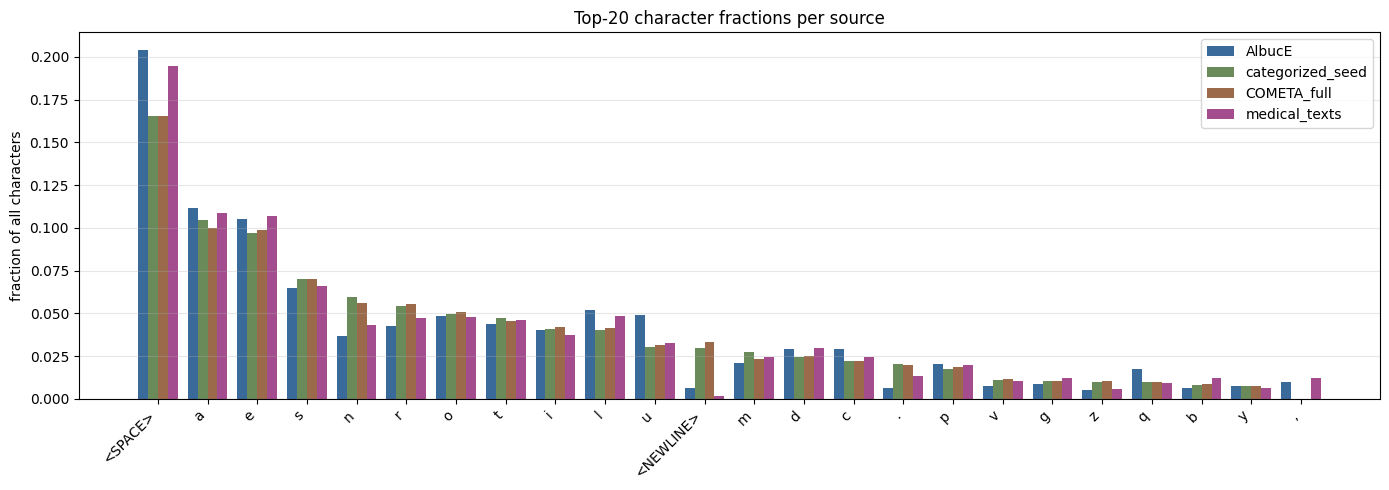

In [7]:
import numpy as np

# Pick the union of the top-N characters across all sources so the chart
# shows the same rows in every panel.
top_n = 20
top_chars = list({c for df in per_source.values() for c in df["char"].head(top_n)})
top_chars = sorted(top_chars, key=lambda c: -merged.loc[c, "categorized_seed"])
chart = merged.loc[top_chars]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(chart))
source_names = [c for c in chart.columns if c != "render"]
n_src = len(source_names)
bar_w = 0.8 / n_src
colors = ["#3a6a9a", "#6a8a5a", "#9a6a4a", "#a44d8e"]
for i, src in enumerate(source_names):
    offset = (i - (n_src - 1) / 2) * bar_w
    ax.bar(x + offset, chart[src], width=bar_w, label=src, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(chart["render"], rotation=45, ha="right")
ax.set_ylabel("fraction of all characters")
ax.set_title(f"Top-{top_n} character fractions per source")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
char_sets = {name: set(df["char"]) for name, df in per_source.items()}

# Each row: (set name, |set|, set rendered)
def _show(label, s):
    print(f"{label:<55}  n={len(s):>3}")
    rendered = sorted(s, key=lambda c: -merged.get(c, pd.Series([0])).max() if c in merged.index else 0)
    for ch in rendered:
        n_each = "  ".join(f"{src}={int(merged_counts.at[ch, src]) if ch in merged_counts.index else 0:>5}" for src in source_names)
        print(f"  {_render(ch):<10}  {n_each}")

_show("only in AlbucE",
      char_sets["AlbucE"] - char_sets["categorized_seed"] - char_sets["COMETA_full"] - char_sets["medical_texts"])
print()
_show("only in categorized_seed",
      char_sets["categorized_seed"] - char_sets["AlbucE"] - char_sets["COMETA_full"] - char_sets["medical_texts"])
print()
_show("only in COMETA_full",
      char_sets["COMETA_full"] - char_sets["AlbucE"] - char_sets["categorized_seed"] - char_sets["medical_texts"])
print()
_show("only in medical_texts",
      char_sets["medical_texts"] - char_sets["AlbucE"] - char_sets["categorized_seed"] - char_sets["COMETA_full"])
print()
_show("in medical_texts but missing from AlbucE",
      char_sets["medical_texts"] - char_sets["AlbucE"])
print()
_show("in AlbucE but missing from medical_texts",
      char_sets["AlbucE"] - char_sets["medical_texts"])
print()
_show("in COMETA_full but missing from categorized_seed",
      char_sets["COMETA_full"] - char_sets["categorized_seed"])
print()
_show("in COMETA_full but missing from AlbucE",
      char_sets["COMETA_full"] - char_sets["AlbucE"])


### What to look at

- If a corpus you're generating synthetic from (`categorized_seed`, `medical_texts`) is missing characters that exist in `AlbucE`, the synthetic generator will never produce them — but the OCR target needs to recognise them. Either supplement the corpus or accept the gap.
- If a corpus has characters that `AlbucE` doesn't, you're training the OCR on inputs the deployment target will never see — usually fine, but bias to keep an eye on.
- Compare `medical_texts` vs `COMETA_full` against `AlbucE`: whichever has a closer character profile is the better feed for the synthetic generator. Big fraction gaps on a common character (>~2 percentage points) usually means the corpus is linguistically off-domain.
